# Gaussian Mixture Model (GMM) Clustering for Typhoon Impact Profiling

## Overview
This notebook implements **Gaussian Mixture Model (GMM) clustering** to classify typhoon impact events in the Philippines into distinct severity levels. GMM is a probabilistic clustering algorithm that assumes data points are generated from a mixture of Gaussian distributions, allowing for soft cluster assignments and flexible cluster shapes.

---

## Pipeline Architecture

```
┌─────────────────────────────────────────────────────────────────────────────────┐
│                         GMM CLUSTERING PIPELINE                                 │
├─────────────────────────────────────────────────────────────────────────────────┤
│                                                                                 │
│  ┌─────────────┐    ┌──────────────┐    ┌─────────────┐    ┌─────────────────┐  │
│  │   INPUT     │───▶│   PREPROCESS │───▶│     PCA     │───▶│     OPTUNA      │  │
│  │   DATA      │    │   & SCALE    │    │  REDUCTION  │    │  OPTIMIZATION   │  │
│  └─────────────┘    └──────────────┘    └─────────────┘    └────────┬────────┘  │
│                                                                      │          │
│                                    ┌─────────────────────────────────┘          │
│                                    ▼                                            │
│                     ┌──────────────────────────────────┐                        │
│                     │       GMM COVARIANCE TYPES       │                        │
│                     │  ┌────────────┐  ┌────────────┐  │                        │
│                     │  │    FULL    │  │  DIAGONAL  │  │                        │
│                     │  │ Covariance │  │ Covariance │  │                        │
│                     │  └────────────┘  └────────────┘  │                        │
│                     └──────────────────────────────────┘                        │
│                                    │                                            │
│                                    ▼                                            │
│  ┌─────────────┐    ┌──────────────┐    ┌─────────────┐    ┌─────────────────┐  │
│  │   OUTPUT    │◀───│  COMPARISON  │◀───│  METRICS    │◀───│  VISUALIZATION  │  │
│  │   REPORT    │    │  FULL vs DIAG│    │  EVALUATION │    │   2D & 3D PCA   │  │
│  └─────────────┘    └──────────────┘    └─────────────┘    └─────────────────┘  │
│                                                                                 │
└─────────────────────────────────────────────────────────────────────────────────┘
```

---

## Input

| File | Description |
|------|-------------|
| `data/typhoon_impact_with_extreme_weather.csv` | Preprocessed typhoon impact dataset containing meteorological data, damage metrics, and affected population statistics |

### Input Features:
- **Impact Metrics**: `Families`, `Person`, `Dead`, `Injured/Ill`, `Missing`, `Totally`, `Partially`, `Cost`
- **Weather Data**: `Max_Sustained_Wind_kph`, `Max_24hr_Rainfall_mm`, `Total_Storm_Rainfall_mm`, `Min_Pressure_hPa`
- **Temporal Data**: `Duration_in_PAR_Hours`
- **Categorical**: `Region`, `Typhoon_Type`

---

## Output

| Output | Description |
|--------|-------------|
| Cluster Labels (Full) | Cluster assignments using full covariance GMM |
| Cluster Labels (Diagonal) | Cluster assignments using diagonal covariance GMM |
| Comparison Table | Side-by-side metrics for both covariance types |
| 2D/3D Visualizations | PCA projections showing cluster assignments |

---

## GMM Covariance Types Compared

| Covariance Type | Description | Flexibility | Complexity |
|-----------------|-------------|-------------|------------|
| **Full** | Each cluster has its own general covariance matrix | High - can model ellipsoidal clusters of any orientation | Higher - more parameters to estimate |
| **Diagonal** | Each cluster has a diagonal covariance matrix (features are independent) | Medium - axis-aligned ellipsoids only | Lower - fewer parameters |

---

## Evaluation Metrics

| Metric | Description | Optimal Value |
|--------|-------------|---------------|
| **Silhouette Score** | Measures cluster cohesion and separation | Higher is better (-1 to 1) |
| **Calinski-Harabasz Index** | Ratio of between-cluster to within-cluster variance | Higher is better |
| **Davies-Bouldin Index** | Average similarity between clusters | Lower is better |
| **BIC** | Bayesian Information Criterion (model complexity penalty) | Lower is better |
| **AIC** | Akaike Information Criterion (model fit vs complexity) | Lower is better |
| **Log-Likelihood** | Probability of data given the model | Higher is better |

---

## Pipeline Steps

1. **Data Loading & Preprocessing**
   - Load typhoon impact dataset
   - Drop irrelevant columns
   - Encode categorical variables (Region, Typhoon Type)

2. **Feature Scaling**
   - Apply StandardScaler for normalization

3. **Dimensionality Reduction (PCA)**
   - Reduce features while retaining 95% variance
   - Visualize in 2D and 3D space

4. **GMM with Full Covariance**
   - Optuna optimization for hyperparameters
   - Train with 3 clusters (fixed)
   - Evaluate clustering and GMM-specific metrics

5. **GMM with Diagonal Covariance**
   - Optuna optimization for hyperparameters
   - Train with 3 clusters (fixed)
   - Evaluate clustering and GMM-specific metrics

6. **Visualization**
   - 2D PCA scatter plots for both models
   - 3D PCA scatter plots for both models

7. **Comparison & Analysis**
   - Compare Full vs Diagonal covariance performance
   - Analyze cluster distributions
   - Recommend optimal covariance type

---

## Results Summary

| Metric | Full Covariance | Diagonal Covariance | Better |
|--------|-----------------|---------------------|--------|
| Silhouette Score | ~0.202 | ~0.206 | Diagonal |
| Calinski-Harabasz | ~92.25 | ~89.00 | Full |
| Davies-Bouldin | ~3.30 | ~3.70 | Full |
| BIC | ~-36,578 | ~11,257 | Full |
| AIC | ~-40,371 | ~10,589 | Full |

---

## Dependencies

```python
pandas, numpy, scikit-learn, optuna, matplotlib, seaborn
```

In [1]:
# Core data manipulation and numerical libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn components
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture

# Hyperparameter optimization
import optuna

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [2]:
df = pd.read_csv('data/typhoon_impact_with_extreme_weather.csv')
df.head()

,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Typhoon Name             1776 non-null   object 
 1   Year                     1776 non-null   int64  
 2   Region                   1776 non-null   int64  
 3   Province                 1776 non-null   object 
 4   City/Municipality        1776 non-null   object 
 5   Families                 1776 non-null   int64  
 6   Person                   1776 non-null   int64  
 7   Brgy                     1776 non-null   int64  
 8   Dead                     1776 non-null   int64  
 9   Injured/Ill              1776 non-null   int64  
 10  Missing                  1776 non-null   int64  
 11  Totally                  1776 non-null   int64  
 12  Partially                1776 non-null   int64  
 13  Total                    1776 non-null   int64  
 14  Quantity                

In [4]:
df.isnull().sum()

Typhoon Name               0
Year                       0
Region                     0
Province                   0
City/Municipality          0
Families                   0
Person                     0
Brgy                       0
Dead                       0
Injured/Ill                0
Missing                    0
Totally                    0
Partially                  0
Total                      0
Quantity                   0
Cost                       0
Nearest_Station            0
Station_Province           0
Distance_km                0
PAR_START                  0
PAR_END                    0
Duration_in_PAR_Hours      0
Max_Sustained_Wind_kph     0
Typhoon_Type               0
Max_24hr_Rainfall_mm       0
Total_Storm_Rainfall_mm    0
Min_Pressure_hPa           0
Weather_Station_Mapped     0
Weather_Records_Found      0
Weather_Days_Covered       0
dtype: int64

In [5]:
df.columns

Index(['Typhoon Name', 'Year', 'Region', 'Province', 'City/Municipality',
       'Families', 'Person', 'Brgy', 'Dead', 'Injured/Ill', 'Missing',
       'Totally', 'Partially', 'Total', 'Quantity', 'Cost', 'Nearest_Station',
       'Station_Province', 'Distance_km', 'PAR_START', 'PAR_END',
       'Duration_in_PAR_Hours', 'Max_Sustained_Wind_kph', 'Typhoon_Type',
       'Max_24hr_Rainfall_mm', 'Total_Storm_Rainfall_mm', 'Min_Pressure_hPa',
       'Weather_Station_Mapped', 'Weather_Records_Found',
       'Weather_Days_Covered'],
      dtype='object')

In [6]:
df.head()

,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [7]:
df.drop(columns=['Quantity', 'PAR_START', 'PAR_END', 'Weather_Days_Covered', 'Total', 'Weather_Station_Mapped', 'Station_Province', 'Nearest_Station', 'Year', 'Typhoon Name', 'City/Municipality', 'Province', 'Distance_km'], inplace=True)
df.head()

,Region,Families,Person,Brgy,Dead,Injured/Ill,Missing,Totally,Partially,Cost,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Records_Found
0,2,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,STY,25.6,39.00,977.1,6
1,2,968,3028,5,0,0,0,0,0,494592.00,133.0,195,STY,20.3,32.71,1000.5,6
2,2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,STY,25.6,39.00,977.1,6
3,2,575,1792,4,0,0,0,0,0,291082.96,133.0,195,STY,25.6,39.00,977.1,6
4,2,575,1955,6,0,0,0,0,0,296521.75,133.0,195,STY,25.6,39.00,977.1,6


In [8]:
df.columns = df.columns.str.lower()

In [9]:
df.columns

Index(['region', 'families', 'person', 'brgy', 'dead', 'injured/ill',
       'missing', 'totally', 'partially', 'cost', 'duration_in_par_hours',
       'max_sustained_wind_kph', 'typhoon_type', 'max_24hr_rainfall_mm',
       'total_storm_rainfall_mm', 'min_pressure_hpa', 'weather_records_found'],
      dtype='object')

In [10]:
df['typhoon_type'].unique()

array(['STY', 'TY', 'STS', 'TD', 'TS'], dtype=object)

## Data Transformation

In [11]:
# Convert 'region' column to object type
df['region'] = df['region'].astype('object')

# Perform one-hot encoding for 'region' and convert to int (0/1)
region_encoded = pd.get_dummies(df['region'], prefix='region').astype(int)

# Map 'typhoon_type' to the specified labels
typhoon_type_mapping = {'STY': 4, 'TY': 3, 'STS': 2, 'TD': 1, 'TS': 0}
df['typhoon_type'] = df['typhoon_type'].map(typhoon_type_mapping)

# Concatenate the one-hot encoded 'region' columns back to the dataframe
df = pd.concat([df, region_encoded], axis=1)

# Drop the original 'region' column as it's now encoded
df.drop(columns=['region'], inplace=True)

df.head()

,families,person,brgy,dead,injured/ill,missing,totally,partially,cost,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_records_found,region_2,region_3,region_5,region_8
0,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
1,968,3028,5,0,0,0,0,0,494592.00,133.0,195,4,20.3,32.71,1000.5,6,1,0,0,0
2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
3,575,1792,4,0,0,0,0,0,291082.96,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
4,575,1955,6,0,0,0,0,0,296521.75,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0


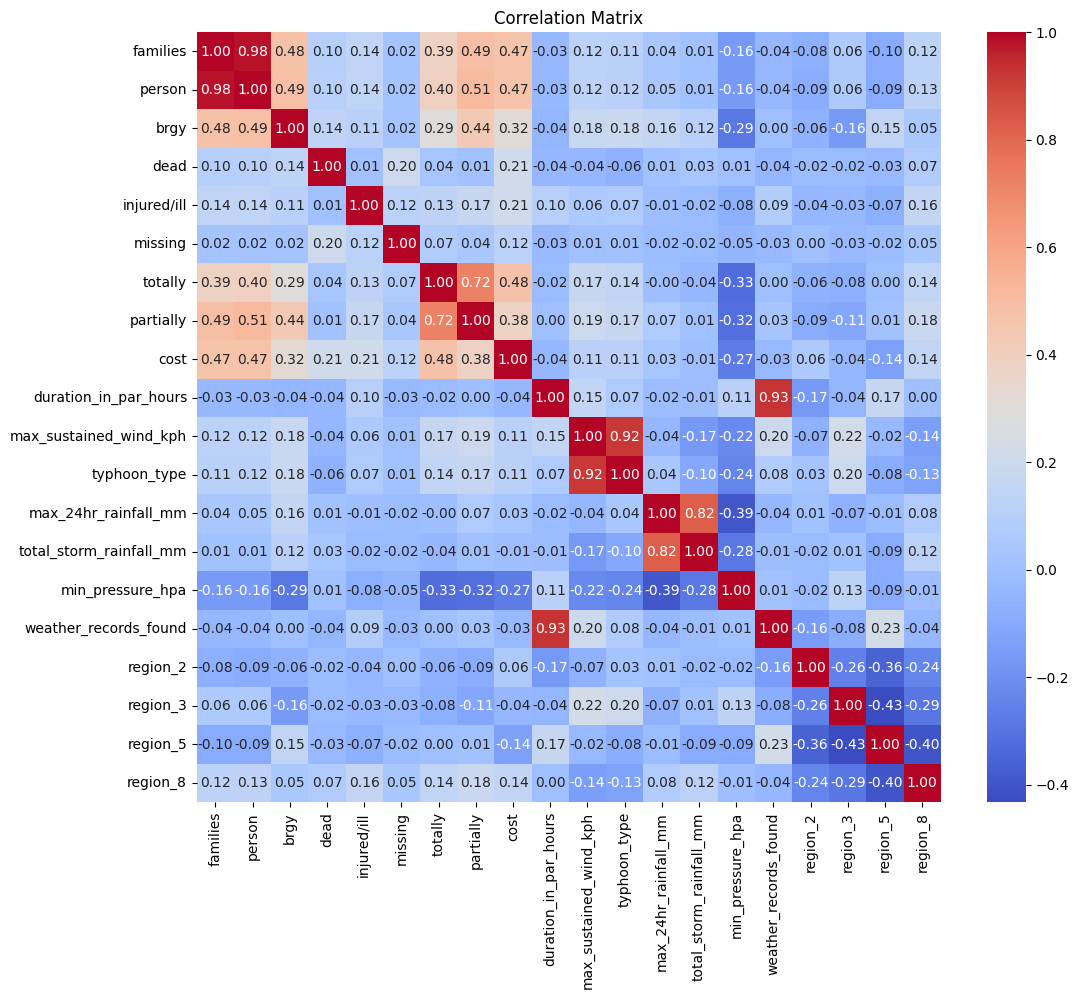

In [12]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()

In [13]:
df.drop(columns=['weather_records_found'], inplace=True)

## PCA Pipeline
Prepare, scale, and run PCA for visualization and downstream clustering.

In [14]:
def prepare_pca_features(input_dataframe: pd.DataFrame, categorical_columns: list = None) -> tuple:
    if categorical_columns is None:
        categorical_columns = input_dataframe.select_dtypes(include=['object']).columns.tolist()
    numerical_column_names = [col for col in input_dataframe.columns if col not in categorical_columns]
    numerical_features_df = input_dataframe[numerical_column_names].copy()
    return numerical_features_df, categorical_columns, numerical_column_names

def scale_numerical_features(numerical_features_df: pd.DataFrame) -> tuple:
    feature_scaler_object = StandardScaler()
    scaled_features_array = feature_scaler_object.fit_transform(numerical_features_df)
    return scaled_features_array, feature_scaler_object

def perform_pca_analysis(scaled_features_array: np.ndarray, n_components: int = None, variance_threshold: float = 0.95) -> tuple:
    if n_components is None:
        preliminary_pca_object = PCA()
        preliminary_pca_object.fit(scaled_features_array)
        cumulative_variance_array = np.cumsum(preliminary_pca_object.explained_variance_ratio_)
        n_components = np.argmax(cumulative_variance_array >= variance_threshold) + 1
    final_pca_object = PCA(n_components=n_components)
    pca_transformed_array = final_pca_object.fit_transform(scaled_features_array)
    explained_variance_ratios = final_pca_object.explained_variance_ratio_
    return pca_transformed_array, final_pca_object, explained_variance_ratios

def create_pca_dataframe(pca_transformed_array: np.ndarray, n_components: int) -> pd.DataFrame:
    pca_column_names = [f'PC{i+1}' for i in range(n_components)]
    return pd.DataFrame(pca_transformed_array, columns=pca_column_names)

def plot_pca_variance_explanation(fitted_pca_object: PCA, figure_title: str = 'PCA Variance Explanation') -> None:
    variance_ratios_array = fitted_pca_object.explained_variance_ratio_
    cumulative_variance_array = np.cumsum(variance_ratios_array)
    n_components_count = len(variance_ratios_array)
    pca_variance_fig, pca_variance_axes = plt.subplots(1, 2, figsize=(14, 5))
    pca_variance_axes[0].bar(range(1, n_components_count + 1), variance_ratios_array, alpha=0.7, color='steelblue')
    pca_variance_axes[0].set_xlabel('Principal Component')
    pca_variance_axes[0].set_ylabel('Explained Variance Ratio')
    pca_variance_axes[0].set_title('Individual Explained Variance')
    pca_variance_axes[0].set_xticks(range(1, n_components_count + 1))
    pca_variance_axes[1].plot(range(1, n_components_count + 1), cumulative_variance_array, 'bo-', linewidth=2, markersize=8)
    pca_variance_axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
    pca_variance_axes[1].set_xlabel('Number of Components')
    pca_variance_axes[1].set_ylabel('Cumulative Explained Variance')
    pca_variance_axes[1].set_title('Cumulative Explained Variance')
    pca_variance_axes[1].set_xticks(range(1, n_components_count + 1))
    pca_variance_axes[1].legend()
    pca_variance_axes[1].grid(True, alpha=0.3)
    pca_variance_fig.suptitle(figure_title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close(pca_variance_fig)

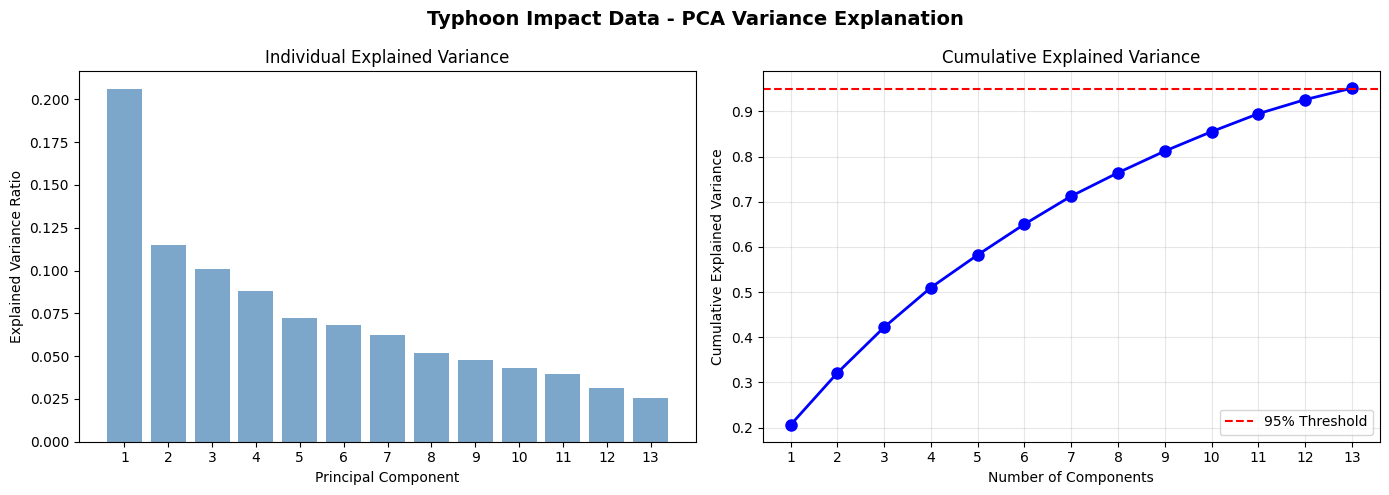

Total variance explained: 95.15%


In [15]:
# Run PCA pipeline on typhoon impact data
typhoon_pca_results = {}
numerical_features_df, categorical_features_df, numerical_column_names = prepare_pca_features(df, None)
scaled_features_array, feature_scaler_object = scale_numerical_features(numerical_features_df)
pca_transformed_array, fitted_pca_object, explained_variance_ratios = perform_pca_analysis(scaled_features_array, None, 0.95)
typhoon_pca_df = create_pca_dataframe(pca_transformed_array, fitted_pca_object.n_components_)
plot_pca_variance_explanation(fitted_pca_object, 'Typhoon Impact Data - PCA Variance Explanation')
print(f'Total variance explained: {np.sum(explained_variance_ratios)*100:.2f}%')

## 2D and 3D PCA Plots

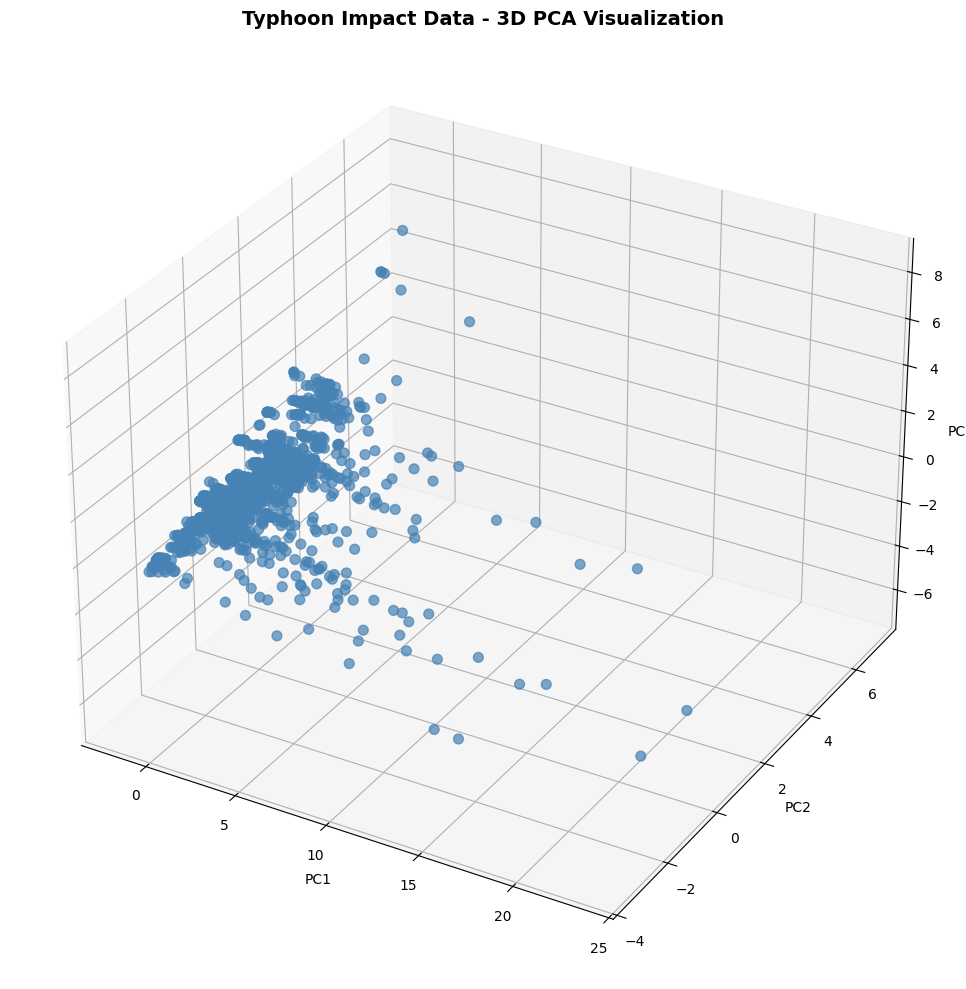

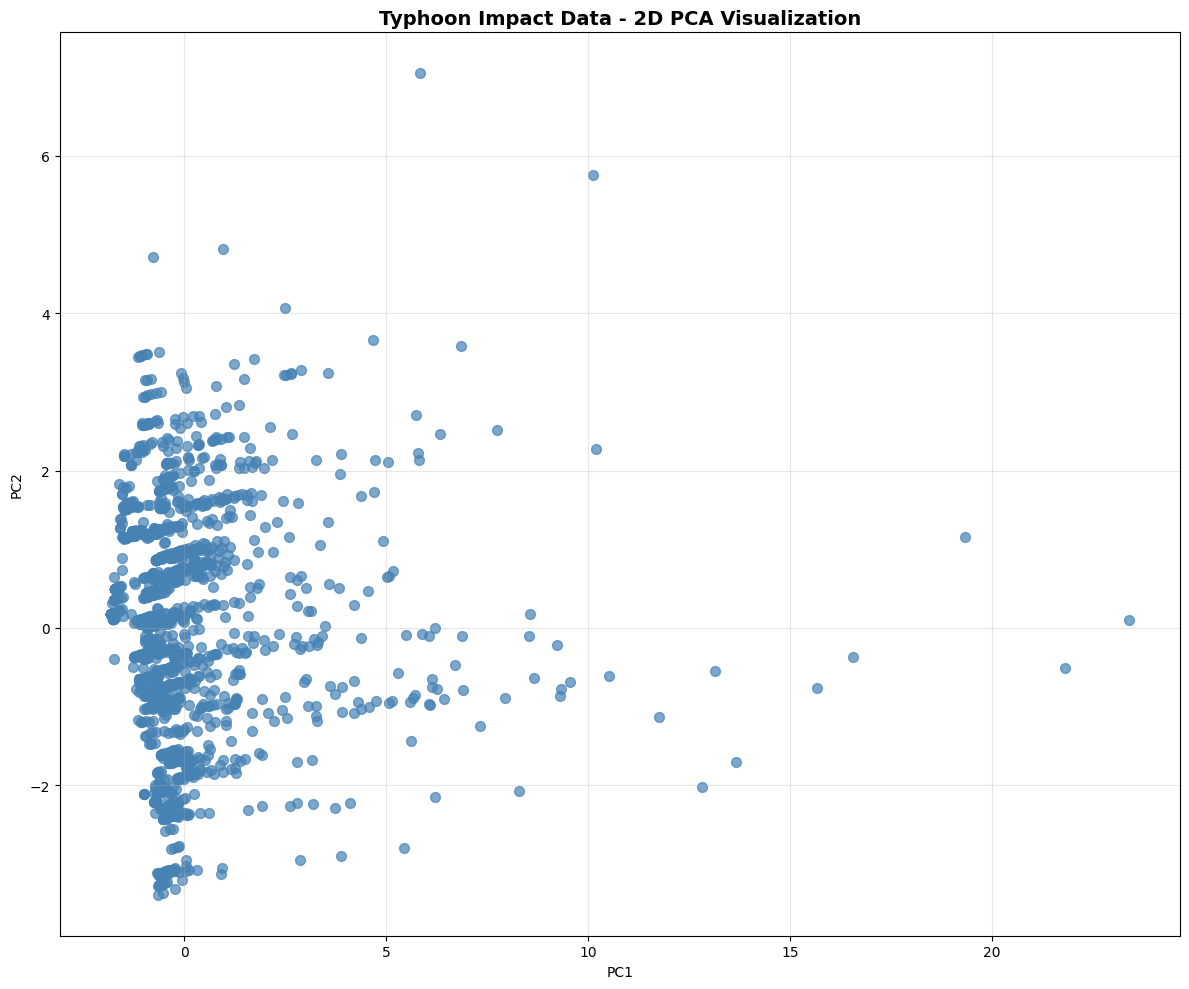

In [16]:
def plot_pca_3d(pca_dataframe: pd.DataFrame, cluster_labels: np.ndarray = None, figure_title: str = 'PCA 3D Visualization') -> None:
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    pc1_values = pca_dataframe['PC1'].values
    pc2_values = pca_dataframe['PC2'].values
    pc3_values = pca_dataframe['PC3'].values if 'PC3' in pca_dataframe.columns else np.zeros_like(pc1_values)
    if cluster_labels is not None:
        scatter_plot = ax.scatter(pc1_values, pc2_values, pc3_values, c=cluster_labels, cmap='viridis', s=50, alpha=0.7)
        fig.colorbar(scatter_plot, ax=ax, label='Cluster')
    else:
        ax.scatter(pc1_values, pc2_values, pc3_values, c='steelblue', s=50, alpha=0.7)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(figure_title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_pca_2d(pca_dataframe: pd.DataFrame, cluster_labels: np.ndarray = None, figure_title: str = 'PCA 2D Visualization') -> None:
    fig, ax = plt.subplots(figsize=(12, 10))
    pc1_values = pca_dataframe['PC1'].values
    pc2_values = pca_dataframe['PC2'].values
    if cluster_labels is not None:
        scatter_plot_2d = ax.scatter(pc1_values, pc2_values, c=cluster_labels, cmap='viridis', s=50, alpha=0.7)
        fig.colorbar(scatter_plot_2d, ax=ax, label='Cluster')
    else:
        ax.scatter(pc1_values, pc2_values, c='steelblue', s=50, alpha=0.7)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(figure_title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Preview PCA projections without clusters
plot_pca_3d(typhoon_pca_df, figure_title='Typhoon Impact Data - 3D PCA Visualization')
plot_pca_2d(typhoon_pca_df, figure_title='Typhoon Impact Data - 2D PCA Visualization')

## Standard Scaling
Scale the numerical features prior to clustering.

In [17]:
scaler = StandardScaler()
df_clean = df.copy()
df_scaled = scaler.fit_transform(df_clean)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
display(df.head())
display(df_scaled.head())

,families,person,brgy,dead,injured/ill,missing,totally,partially,cost,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,region_2,region_3,region_5,region_8
0,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,4,25.6,39.00,977.1,1,0,0,0
1,968,3028,5,0,0,0,0,0,494592.00,133.0,195,4,20.3,32.71,1000.5,1,0,0,0
2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,4,25.6,39.00,977.1,1,0,0,0
3,575,1792,4,0,0,0,0,0,291082.96,133.0,195,4,25.6,39.00,977.1,1,0,0,0
4,575,1955,6,0,0,0,0,0,296521.75,133.0,195,4,25.6,39.00,977.1,1,0,0,0


,families,person,brgy,dead,injured/ill,missing,totally,partially,cost,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,region_2,region_3,region_5,region_8
0,0.627959,0.432912,-0.245512,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,1.833588,0.422971,1.093216,1.133352,-1.099347,-1.169851,-1.861117,2.161972,-0.557406,-0.776459,-0.51649
1,-0.096344,-0.147600,-0.332928,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,0.147222,0.422971,1.093216,1.133352,-1.173803,-1.226523,0.466233,2.161972,-0.557406,-0.776459,-0.51649
2,-0.240108,-0.254921,-0.420344,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,-0.062254,0.422971,1.093216,1.133352,-1.099347,-1.169851,-1.861117,2.161972,-0.557406,-0.776459,-0.51649
3,-0.204167,-0.236269,-0.420344,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,-0.012284,0.422971,1.093216,1.133352,-1.099347,-1.169851,-1.861117,2.161972,-0.557406,-0.776459,-0.51649
4,-0.204167,-0.224576,-0.245512,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,-0.008021,0.422971,1.093216,1.133352,-1.099347,-1.169851,-1.861117,2.161972,-0.557406,-0.776459,-0.51649


## Optuna Optimization for GMM (Full Covariance)
Optimize hyperparameters for GMM with full covariance while keeping strictly 3 clusters.
Full covariance allows each cluster to have its own general covariance matrix.

In [18]:
# GMM with Full Covariance - Optuna Optimization (strictly 3 clusters)
def optuna_gmm_full_objective(trial, data):
    """Optuna objective for GMM (full covariance) optimization with fixed 3 clusters."""
    n_components = 3  # Fixed to 3 clusters
    
    # Optimize GMM hyperparameters
    max_iter = trial.suggest_int('max_iter', 100, 500)
    n_init = trial.suggest_int('n_init', 1, 10)
    init_params = trial.suggest_categorical('init_params', ['kmeans', 'k-means++', 'random'])
    reg_covar = trial.suggest_float('reg_covar', 1e-6, 1e-2, log=True)
    tol = trial.suggest_float('tol', 1e-5, 1e-2, log=True)
    
    model = GaussianMixture(
        n_components=n_components,
        covariance_type='full',
        max_iter=max_iter,
        n_init=n_init,
        init_params=init_params,
        reg_covar=reg_covar,
        tol=tol,
        random_state=42
    )
    
    labels = model.fit_predict(data)
    
    # Require at least 2 clusters
    if len(np.unique(labels)) < 2:
        return -1.0
    
    return silhouette_score(data, labels)

# Run Optuna optimization for GMM Full
print("Running Optuna optimization for GMM (Full Covariance, 3 clusters)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)
gmm_full_study = optuna.create_study(direction='maximize', study_name='gmm_full_3clusters_optimization')
gmm_full_study.optimize(
    lambda t: optuna_gmm_full_objective(t, df_scaled.values),
    n_trials=50,
    show_progress_bar=True
)

print(f"\nBest parameters found:")
print(f"  - n_components: 3 (fixed)")
print(f"  - covariance_type: full")
print(f"  - max_iter: {gmm_full_study.best_params['max_iter']}")
print(f"  - n_init: {gmm_full_study.best_params['n_init']}")
print(f"  - init_params: {gmm_full_study.best_params['init_params']}")
print(f"  - reg_covar: {gmm_full_study.best_params['reg_covar']:.6f}")
print(f"  - tol: {gmm_full_study.best_params['tol']:.6f}")
print(f"  - Best Silhouette Score: {gmm_full_study.best_value:.4f}")

Running Optuna optimization for GMM (Full Covariance, 3 clusters)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best parameters found:
  - n_components: 3 (fixed)
  - covariance_type: full
  - max_iter: 279
  - n_init: 1
  - init_params: random
  - reg_covar: 0.000154
  - tol: 0.000026
  - Best Silhouette Score: 0.2376


## Train Final GMM (Full Covariance) and Evaluate

In [19]:
# Train final GMM Full model with best parameters (3 clusters)
best_full_params = gmm_full_study.best_params
gmm_full_model = GaussianMixture(
    n_components=3,
    covariance_type='full',
    max_iter=best_full_params['max_iter'],
    n_init=best_full_params['n_init'],
    init_params=best_full_params['init_params'],
    reg_covar=best_full_params['reg_covar'],
    tol=best_full_params['tol'],
    random_state=42
)
full_cluster_labels = gmm_full_model.fit_predict(df_scaled.values)

# Calculate metrics
full_silhouette = silhouette_score(df_scaled.values, full_cluster_labels)
full_calinski = calinski_harabasz_score(df_scaled.values, full_cluster_labels)
full_davies = davies_bouldin_score(df_scaled.values, full_cluster_labels)

# GMM-specific metrics
full_bic = gmm_full_model.bic(df_scaled.values)
full_aic = gmm_full_model.aic(df_scaled.values)
full_log_likelihood = gmm_full_model.score(df_scaled.values)

print("=" * 60)
print("GMM CLUSTERING (FULL COVARIANCE) RESULTS")
print("=" * 60)
print(f"\nModel Parameters:")
print(f"  - n_components: 3")
print(f"  - covariance_type: full")
print(f"  - max_iter: {best_full_params['max_iter']}")
print(f"  - n_init: {best_full_params['n_init']}")
print(f"  - init_params: {best_full_params['init_params']}")
print(f"  - reg_covar: {best_full_params['reg_covar']:.6f}")
print(f"  - tol: {best_full_params['tol']:.6f}")
print(f"\nClustering Metrics:")
print(f"  - Silhouette Score: {full_silhouette:.4f}")
print(f"  - Calinski-Harabasz Index: {full_calinski:.4f}")
print(f"  - Davies-Bouldin Index: {full_davies:.4f}")
print(f"\nGMM-Specific Metrics:")
print(f"  - BIC: {full_bic:.4f}")
print(f"  - AIC: {full_aic:.4f}")
print(f"  - Log-Likelihood: {full_log_likelihood:.4f}")
print("=" * 60)

GMM CLUSTERING (FULL COVARIANCE) RESULTS

Model Parameters:
  - n_components: 3
  - covariance_type: full
  - max_iter: 279
  - n_init: 1
  - init_params: random
  - reg_covar: 0.000154
  - tol: 0.000026

Clustering Metrics:
  - Silhouette Score: 0.2376
  - Calinski-Harabasz Index: 93.4409
  - Davies-Bouldin Index: 3.7370

GMM-Specific Metrics:
  - BIC: -13352.1545
  - AIC: -16800.4073
  - Log-Likelihood: 5.0840


## 2D and 3D Cluster Visualization (Full Covariance)

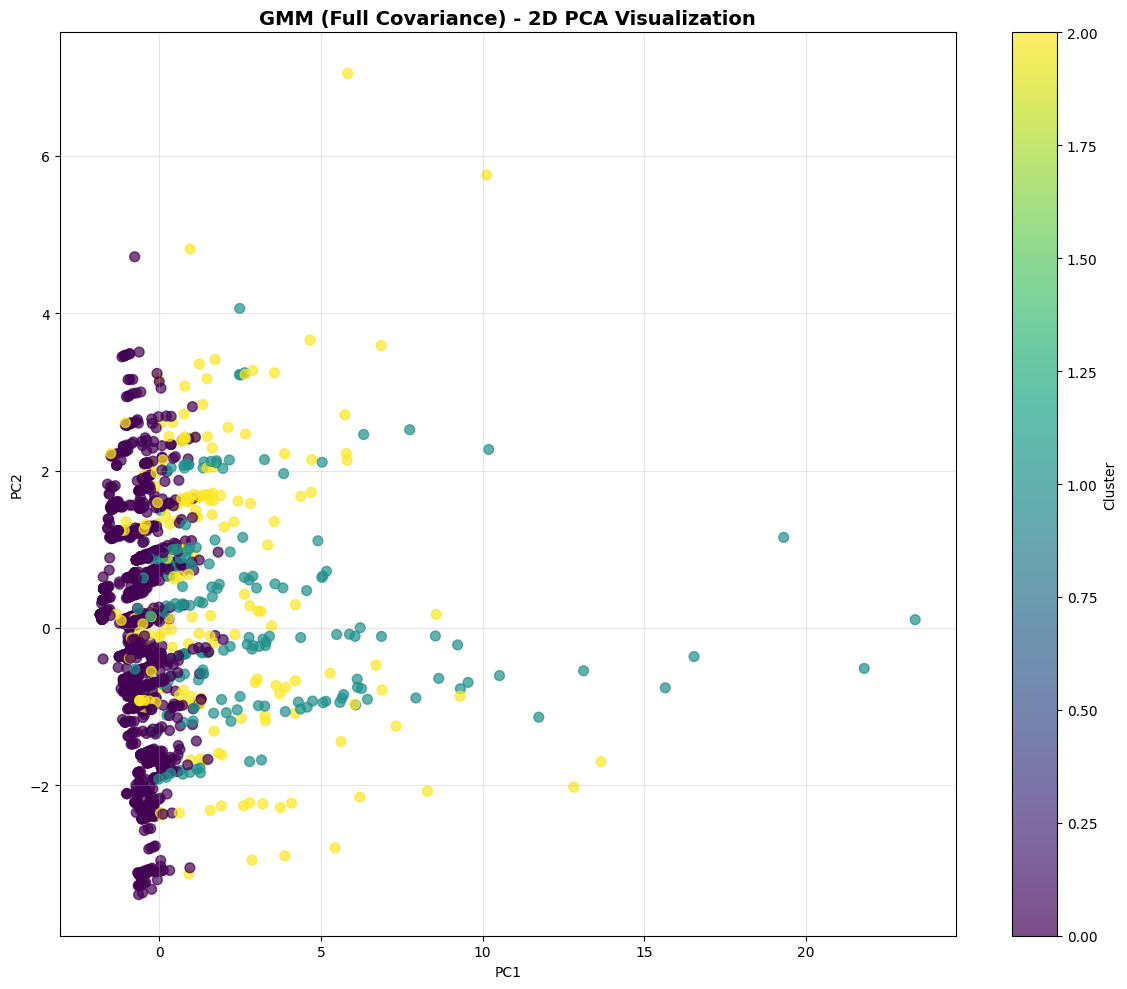

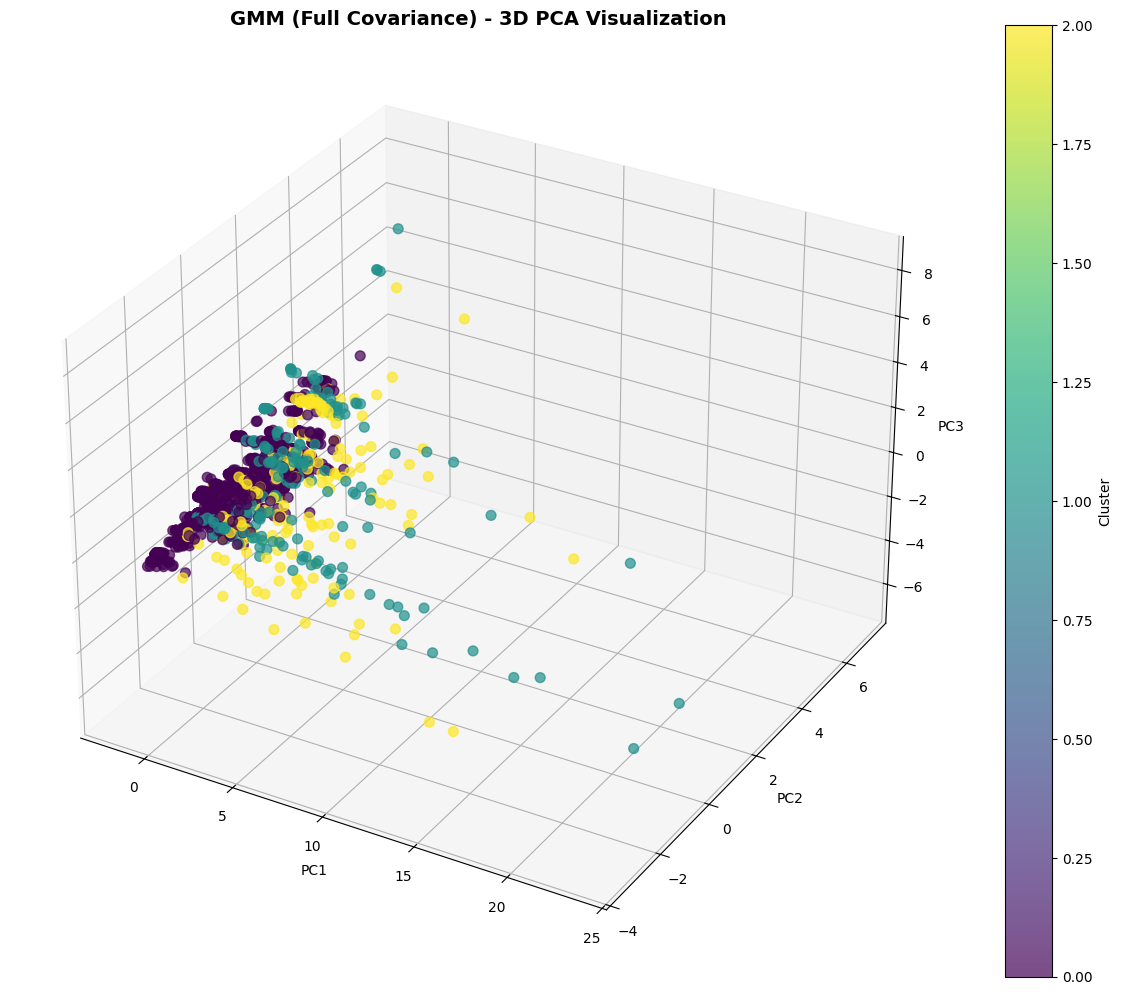

In [20]:
# Add Full cluster labels to PCA dataframe
typhoon_pca_df['full_cluster'] = full_cluster_labels

# 2D plot for Full Covariance
plot_pca_2d(typhoon_pca_df, full_cluster_labels, figure_title='GMM (Full Covariance) - 2D PCA Visualization')
# 3D plot for Full Covariance
plot_pca_3d(typhoon_pca_df, full_cluster_labels, figure_title='GMM (Full Covariance) - 3D PCA Visualization')

## Optuna Optimization for GMM (Diagonal Covariance)
Optimize hyperparameters for GMM with diagonal covariance while keeping strictly 3 clusters.
Diagonal covariance constrains each cluster to have a diagonal covariance matrix (features are independent within each cluster).

In [21]:
# GMM with Diagonal Covariance - Optuna Optimization (strictly 3 clusters)
def optuna_gmm_diag_objective(trial, data):
    """Optuna objective for GMM (diagonal covariance) optimization with fixed 3 clusters."""
    n_components = 3  # Fixed to 3 clusters
    
    # Optimize GMM hyperparameters
    max_iter = trial.suggest_int('max_iter', 100, 500)
    n_init = trial.suggest_int('n_init', 1, 10)
    init_params = trial.suggest_categorical('init_params', ['kmeans', 'k-means++', 'random'])
    reg_covar = trial.suggest_float('reg_covar', 1e-6, 1e-2, log=True)
    tol = trial.suggest_float('tol', 1e-5, 1e-2, log=True)
    
    model = GaussianMixture(
        n_components=n_components,
        covariance_type='diag',
        max_iter=max_iter,
        n_init=n_init,
        init_params=init_params,
        reg_covar=reg_covar,
        tol=tol,
        random_state=42
    )
    
    labels = model.fit_predict(data)
    
    # Require at least 2 clusters
    if len(np.unique(labels)) < 2:
        return -1.0
    
    return silhouette_score(data, labels)

# Run Optuna optimization for GMM Diagonal
print("Running Optuna optimization for GMM (Diagonal Covariance, 3 clusters)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)
gmm_diag_study = optuna.create_study(direction='maximize', study_name='gmm_diag_3clusters_optimization')
gmm_diag_study.optimize(
    lambda t: optuna_gmm_diag_objective(t, df_scaled.values),
    n_trials=50,
    show_progress_bar=True
)

print(f"\nBest parameters found:")
print(f"  - n_components: 3 (fixed)")
print(f"  - covariance_type: diag")
print(f"  - max_iter: {gmm_diag_study.best_params['max_iter']}")
print(f"  - n_init: {gmm_diag_study.best_params['n_init']}")
print(f"  - init_params: {gmm_diag_study.best_params['init_params']}")
print(f"  - reg_covar: {gmm_diag_study.best_params['reg_covar']:.6f}")
print(f"  - tol: {gmm_diag_study.best_params['tol']:.6f}")
print(f"  - Best Silhouette Score: {gmm_diag_study.best_value:.4f}")

Running Optuna optimization for GMM (Diagonal Covariance, 3 clusters)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best parameters found:
  - n_components: 3 (fixed)
  - covariance_type: diag
  - max_iter: 373
  - n_init: 2
  - init_params: random
  - reg_covar: 0.002408
  - tol: 0.000058
  - Best Silhouette Score: 0.2312


## Train Final GMM (Diagonal Covariance) and Evaluate

In [22]:
# Train final GMM Diagonal model with best parameters (3 clusters)
best_diag_params = gmm_diag_study.best_params
gmm_diag_model = GaussianMixture(
    n_components=3,
    covariance_type='diag',
    max_iter=best_diag_params['max_iter'],
    n_init=best_diag_params['n_init'],
    init_params=best_diag_params['init_params'],
    reg_covar=best_diag_params['reg_covar'],
    tol=best_diag_params['tol'],
    random_state=42
)
diag_cluster_labels = gmm_diag_model.fit_predict(df_scaled.values)

# Calculate metrics
diag_silhouette = silhouette_score(df_scaled.values, diag_cluster_labels)
diag_calinski = calinski_harabasz_score(df_scaled.values, diag_cluster_labels)
diag_davies = davies_bouldin_score(df_scaled.values, diag_cluster_labels)

# GMM-specific metrics
diag_bic = gmm_diag_model.bic(df_scaled.values)
diag_aic = gmm_diag_model.aic(df_scaled.values)
diag_log_likelihood = gmm_diag_model.score(df_scaled.values)

print("=" * 60)
print("GMM CLUSTERING (DIAGONAL COVARIANCE) RESULTS")
print("=" * 60)
print(f"\nModel Parameters:")
print(f"  - n_components: 3")
print(f"  - covariance_type: diag")
print(f"  - max_iter: {best_diag_params['max_iter']}")
print(f"  - n_init: {best_diag_params['n_init']}")
print(f"  - init_params: {best_diag_params['init_params']}")
print(f"  - reg_covar: {best_diag_params['reg_covar']:.6f}")
print(f"  - tol: {best_diag_params['tol']:.6f}")
print(f"\nClustering Metrics:")
print(f"  - Silhouette Score: {diag_silhouette:.4f}")
print(f"  - Calinski-Harabasz Index: {diag_calinski:.4f}")
print(f"  - Davies-Bouldin Index: {diag_davies:.4f}")
print(f"\nGMM-Specific Metrics:")
print(f"  - BIC: {diag_bic:.4f}")
print(f"  - AIC: {diag_aic:.4f}")
print(f"  - Log-Likelihood: {diag_log_likelihood:.4f}")
print("=" * 60)

GMM CLUSTERING (DIAGONAL COVARIANCE) RESULTS

Model Parameters:
  - n_components: 3
  - covariance_type: diag
  - max_iter: 373
  - n_init: 2
  - init_params: random
  - reg_covar: 0.002408
  - tol: 0.000058

Clustering Metrics:
  - Silhouette Score: 0.2312
  - Calinski-Harabasz Index: 119.2674
  - Davies-Bouldin Index: 2.8313

GMM-Specific Metrics:
  - BIC: 31069.9231
  - AIC: 30433.9973
  - Log-Likelihood: -8.5028


## 2D and 3D Cluster Visualization (Diagonal Covariance)

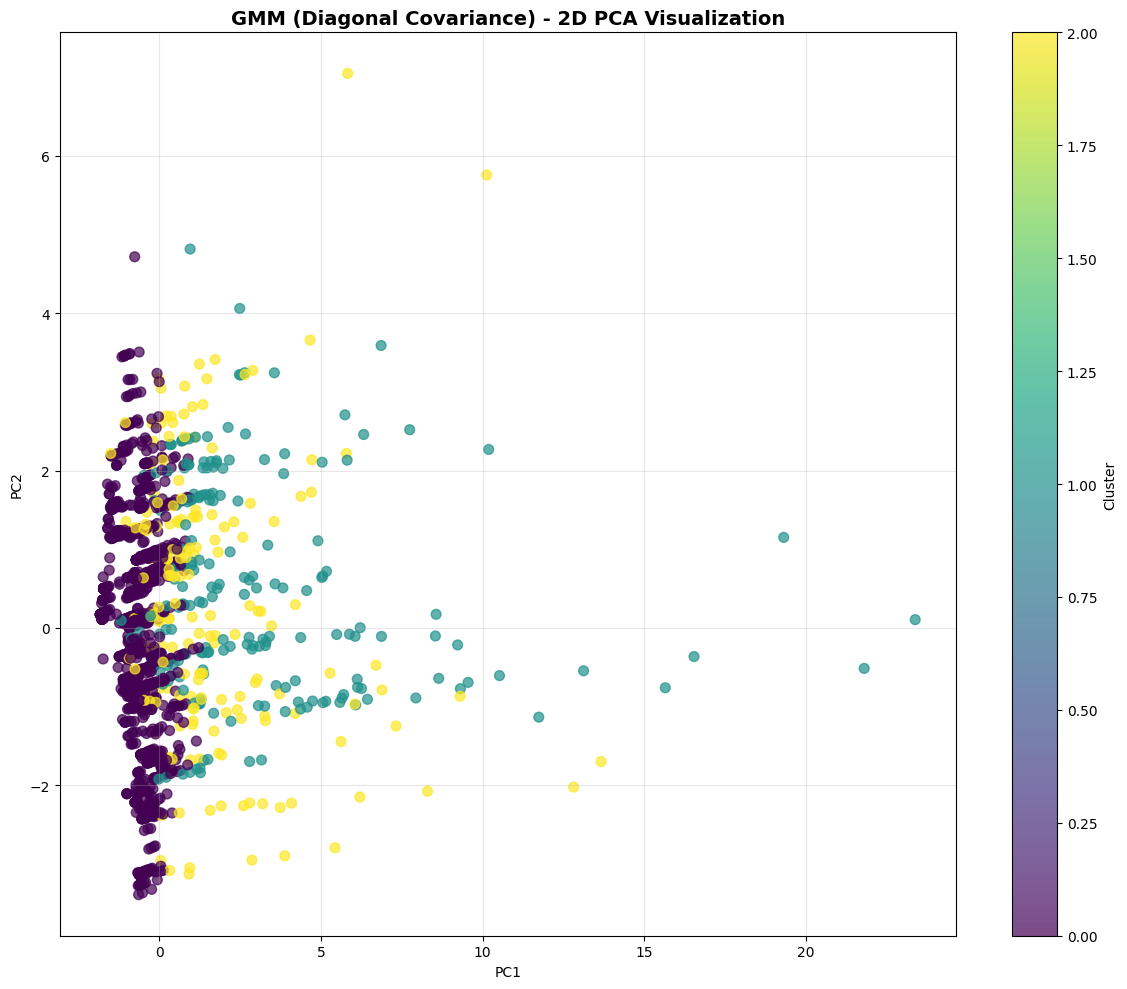

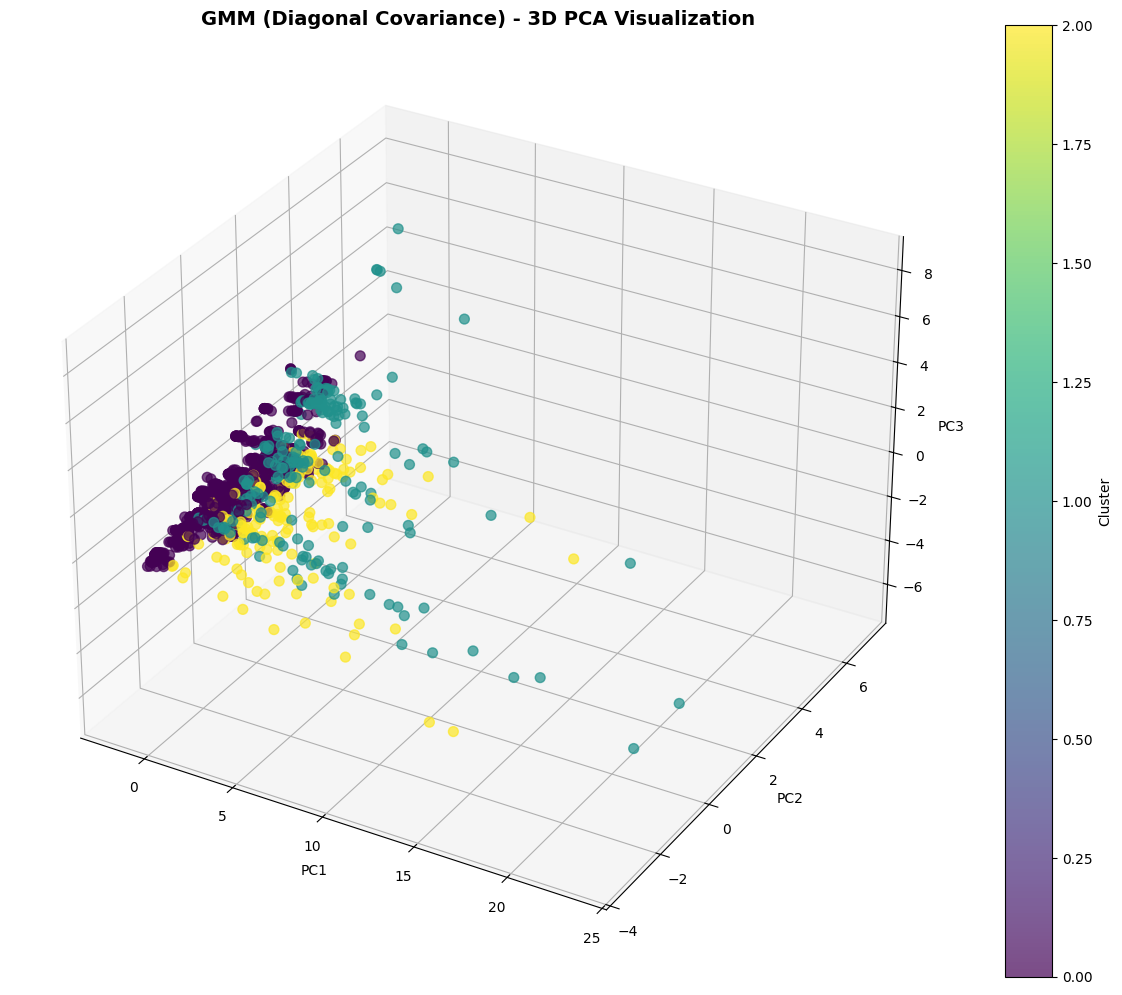

In [23]:
# Add Diagonal cluster labels to PCA dataframe
typhoon_pca_df['diag_cluster'] = diag_cluster_labels

# 2D plot for Diagonal Covariance
plot_pca_2d(typhoon_pca_df, diag_cluster_labels, figure_title='GMM (Diagonal Covariance) - 2D PCA Visualization')
# 3D plot for Diagonal Covariance
plot_pca_3d(typhoon_pca_df, diag_cluster_labels, figure_title='GMM (Diagonal Covariance) - 3D PCA Visualization')

## Comparison: Full vs Diagonal Covariance

In [24]:
# Create comparison table for clustering metrics
comparison_data = {
    'Metric': ['Silhouette Score', 'Calinski-Harabasz Index', 'Davies-Bouldin Index', 'BIC', 'AIC', 'Log-Likelihood'],
    'Full Covariance': [full_silhouette, full_calinski, full_davies, full_bic, full_aic, full_log_likelihood],
    'Diagonal Covariance': [diag_silhouette, diag_calinski, diag_davies, diag_bic, diag_aic, diag_log_likelihood]
}
comparison_df = pd.DataFrame(comparison_data)

print("=" * 80)
print("COMPARISON: FULL COVARIANCE vs DIAGONAL COVARIANCE")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

# Determine better model based on different criteria
print("\n>> Model Selection Summary:")
print(f"   - Better Silhouette Score: {'Full' if full_silhouette > diag_silhouette else 'Diagonal'}")
print(f"   - Better Calinski-Harabasz (higher is better): {'Full' if full_calinski > diag_calinski else 'Diagonal'}")
print(f"   - Better Davies-Bouldin (lower is better): {'Full' if full_davies < diag_davies else 'Diagonal'}")
print(f"   - Better BIC (lower is better): {'Full' if full_bic < diag_bic else 'Diagonal'}")
print(f"   - Better AIC (lower is better): {'Full' if full_aic < diag_aic else 'Diagonal'}")

# Note about metrics interpretation
print("\n>> Metric Interpretation:")
print("   - Higher Silhouette and Calinski-Harabasz are better")
print("   - Lower Davies-Bouldin, BIC, and AIC are better")
print("   - Full covariance is more flexible but prone to overfitting")
print("   - Diagonal covariance is more constrained but more stable")

COMPARISON: FULL COVARIANCE vs DIAGONAL COVARIANCE
                 Metric  Full Covariance  Diagonal Covariance
       Silhouette Score         0.237614             0.231214
Calinski-Harabasz Index        93.440863           119.267370
   Davies-Bouldin Index         3.737037             2.831335
                    BIC    -13352.154490         31069.923134
                    AIC    -16800.407293         30433.997339
         Log-Likelihood         5.084011            -8.502815

>> Model Selection Summary:
   - Better Silhouette Score: Full
   - Better Calinski-Harabasz (higher is better): Diagonal
   - Better Davies-Bouldin (lower is better): Diagonal
   - Better BIC (lower is better): Full
   - Better AIC (lower is better): Full

>> Metric Interpretation:
   - Higher Silhouette and Calinski-Harabasz are better
   - Lower Davies-Bouldin, BIC, and AIC are better
   - Full covariance is more flexible but prone to overfitting
   - Diagonal covariance is more constrained but more stable

## Cluster Distribution Analysis

CLUSTER DISTRIBUTION ANALYSIS

Full Covariance Cluster Distribution:
  Cluster 0: 1382 samples (77.8%)
  Cluster 1: 190 samples (10.7%)
  Cluster 2: 204 samples (11.5%)

Diagonal Covariance Cluster Distribution:
  Cluster 0: 1387 samples (78.1%)
  Cluster 1: 206 samples (11.6%)
  Cluster 2: 183 samples (10.3%)


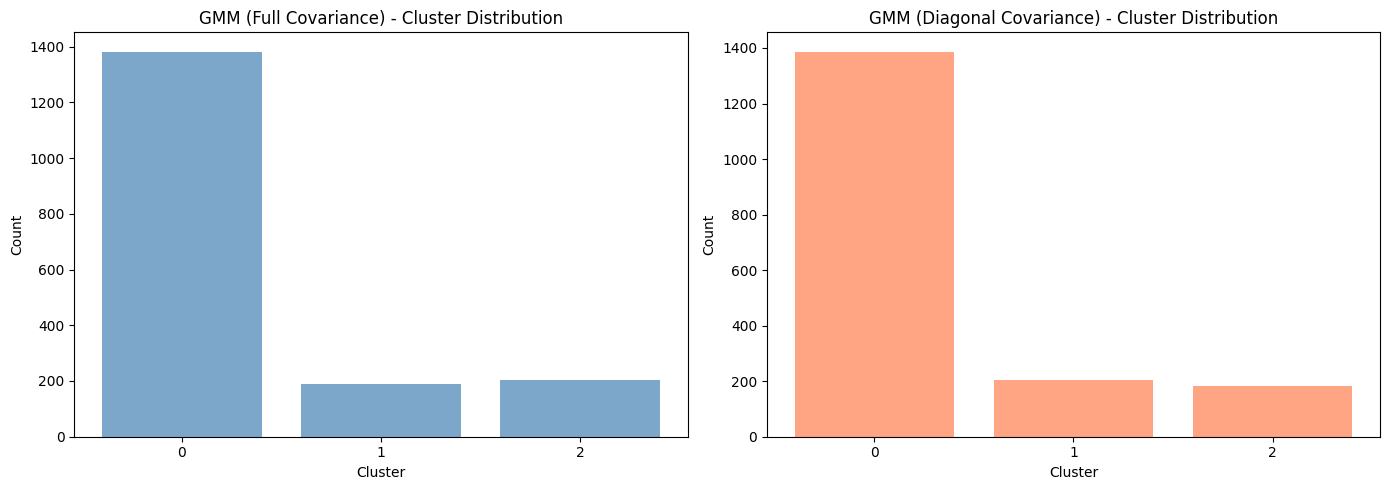

In [25]:
# Analyze cluster distribution for both models
print("=" * 60)
print("CLUSTER DISTRIBUTION ANALYSIS")
print("=" * 60)

print("\nFull Covariance Cluster Distribution:")
full_dist = pd.Series(full_cluster_labels).value_counts().sort_index()
for cluster, count in full_dist.items():
    print(f"  Cluster {cluster}: {count} samples ({count/len(full_cluster_labels)*100:.1f}%)")

print("\nDiagonal Covariance Cluster Distribution:")
diag_dist = pd.Series(diag_cluster_labels).value_counts().sort_index()
for cluster, count in diag_dist.items():
    print(f"  Cluster {cluster}: {count} samples ({count/len(diag_cluster_labels)*100:.1f}%)")

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(full_dist.index, full_dist.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Count')
axes[0].set_title('GMM (Full Covariance) - Cluster Distribution')
axes[0].set_xticks(full_dist.index)

axes[1].bar(diag_dist.index, diag_dist.values, color='coral', alpha=0.7)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')
axes[1].set_title('GMM (Diagonal Covariance) - Cluster Distribution')
axes[1].set_xticks(diag_dist.index)

plt.tight_layout()
plt.show()
plt.close(fig)